# **Projeto: Previsão de Intenção de Compra em E-commerce**

## Introdução

Este projeto desenvolve um pipeline completo de Ciência de Dados para resolver um problema clássico de classificação binária no varejo online: prever se um visitante de um e-commerce realizará uma compra ou não.

Utilizando algoritmos de Aprendizado de Máquina Supervisionado (Regressão Logística e Random Forest), o trabalho abrange desde a análise exploratória e tratamento de dados até a modelagem preditiva e avaliação de desempenho, focando na identificação de padrões de navegação que levam à conversão.

## Contexto e Motivação

No cenário competitivo do comércio eletrônico, a taxa média de conversão costuma ser baixa (frequentemente inferior a 3%). Isso significa que a vasta maioria do tráfego pago ou orgânico não gera receita imediata.

Entender a **Jornada do Cliente** e identificar em tempo real quais visitantes demonstram alta propensão à compra é um diferencial estratégico. Ao antecipar a intenção do usuário (comprar vs. apenas navegar), empresas podem:
* **Otimizar Marketing:** Direcionar verbas de retargeting apenas para usuários com alta probabilidade de conversão.
* **Personalizar a Experiência:** Oferecer incentivos dinâmicos (como cupons ou frete grátis) no momento certo para indecisos.
* **Aumentar o ROI:** Reduzir o Custo de Aquisição de Clientes (CAC) focando nos leads qualificados.

## Objetivos

O objetivo principal é construir um modelo preditivo robusto capaz de classificar a sessão de um usuário como **Revenue = True** (Comprou) ou **Revenue = False** (Não Comprou).

Para atingir isso, os objetivos específicos são:
1.  **Análise Exploratória (EDA):** Identificar correlações entre variáveis de navegação (ex: *PageValues*, *ExitRates*, *ProductRelated_Duration*) e a decisão de compra.
2.  **Pré-processamento:** Realizar tratamento de variáveis categóricas (Encoding), padronização de dados numéricos e separação de bases de treino/teste.
3.  **Modelagem e Comparação:** Treinar e comparar o desempenho de um modelo linear (**Regressão Logística**) contra um modelo de *ensemble* não-linear (**Random Forest**).
4.  **Avaliação de Negócio:** Interpretar as métricas de acurácia e matriz de confusão para determinar qual modelo oferece a melhor confiabilidade para implantação em produção.

## Sobre os Dados

O conjunto de dados consiste em vetores de características pertencentes a **12.330 sessões** de usuários. O dataset foi construído de forma que cada sessão pertença a um usuário diferente em um período de 1 ano, evitando viés de campanhas específicas ou sazonalidade isolada.

As variáveis (features) podem ser agrupadas em três categorias principais:

1.  **Métricas de Navegação (Numéricas):**
    * `Administrative`, `Informational`, `ProductRelated`: Quantidade de páginas visitadas nessas categorias.
    * `_Duration`: Tempo total gasto em cada categoria de página.

2.  **Métricas de Engajamento (Google Analytics):**
    * `BounceRates` (Taxa de Rejeição): Porcentagem de visitantes que entram e saem sem interagir.
    * `ExitRates` (Taxa de Saída): Porcentagem de pageviews que foram a última na sessão.
    * `PageValues`: Valor médio da página para uma transação (indicador crítico de conversão).

3.  **Informações do Visitante e Contexto (Categóricas):**
    * `SpecialDay`: Proximidade de datas comemorativas (ex: Dia das Mães).
    * `Month`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`.
    * `VisitorType`: Visitante Novo vs. Retornante.

**Variável Alvo (Target):**
* `Revenue`: Binária (True/False) indicando se a sessão resultou em uma transação finalizada.

## Metodologia Aplicada

Para garantir a reprodutibilidade e a robustez dos resultados, o projeto seguiu um pipeline estruturado de Ciência de Dados:

1.  **Análise Exploratória de Dados (EDA):**
    * Investigação da distribuição da variável alvo (`Revenue`) para checar desbalanceamento.
    * Análise de correlação (Mapa de Calor) para identificar colinearidade entre variáveis.
    * Visualização de atributos categóricos em relação à conversão.

2.  **Pré-processamento e Transformação:**
    * **Codificação (Encoding):** Transformação de variáveis categóricas (como `Month` e `VisitorType`) em valores numéricos compreensíveis pelos algoritmos.
    * **Padronização (Scaling):** Aplicação de `StandardScaler` para colocar todas as variáveis na mesma escala, etapa essencial para o bom desempenho da Regressão Logística.
    * **Divisão (Split):** Separação dos dados em conjuntos de Treino e Teste para validar a generalização do modelo.

3.  **Modelagem Preditiva:**
    * **Baseline (Regressão Logística):** Utilizado como linha de base devido à sua simplicidade e interpretabilidade.
    * **Modelo Avançado (Random Forest):** Utilizado para capturar relações não-lineares complexas e interações entre variáveis de navegação.

4.  **Avaliação de Desempenho:**
    * Comparação direta utilizando a métrica de **Acurácia**.
    * Análise da **Matriz de Confusão** para entender os falsos positivos e falsos negativos.

## ETAPA 1: Preparação dos Dados

A preparação de dados começa com a Exploração e Limpeza, fase crucial para identificar e tratar ausências, inconsistências e outliers, garantindo a integridade dos dados para a modelagem. Em seguida, a Análise aprofundada, com gráficos e estatísticas, cria uma storytelling rica, gerando insights que orientam as decisões e o projeto.


In [ ]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para os modelos de machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

: 

### 1.1 - Integridade dos dados 

In [ ]:
# Carregamento dos dados
df = pd.read_csv('marketing_campaign.csv', delimiter=';')

# Verificando dados
df

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,46,709,43,182,42,118,247,4,5,0,1
2236,1946,PhD,Together,64014.0,2,56,406,0,30,0,0,8,5,7,0,1
2237,1981,Graduation,Divorced,56981.0,0,91,908,48,217,32,12,24,13,6,0,0
2238,1956,Master,Together,69245.0,0,8,428,30,214,80,30,61,10,3,0,1


In [3]:
# --- Inspeção Geral ---
print("--- 1. Informações Gerais do Dataset ---")
print(df.info())

--- 1. Informações Gerais do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   object 
 2   Marital_Status     2240 non-null   object 
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-nul

In [4]:
print("\n--- 2. Verificação de Dados Ausentes ---")
nulos = df.isnull().sum()
print(nulos[nulos > 0])


--- 2. Verificação de Dados Ausentes ---
Income    24
dtype: int64


In [5]:
print("\n--- 3. Estatísticas Descritivas (Numéricas) ---")
display(df.describe().T)


--- 3. Estatísticas Descritivas (Numéricas) ---


,count,mean,std,min,25%,50%,75%,max
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2240.0,27.062946,41.280498,0.0,1.00,8.0,33.00,263.0
MntGoldProds,2240.0,44.021875,52.167439,0.0,9.00,24.0,56.00,362.0


In [ ]:
print("\n--- 4. Inspeção Técnica e Consistência de Categorias ---")

# Filtrar apenas colunas categóricas
cols_categoricas = df.select_dtypes(include=['object']).columns

for col in cols_categoricas:
    print(f"\nColuna: {col}")
    print(df[col].value_counts())
    print("-" * 30)

# Verificação de espaços em branco ou inconsistência de caixa (Maiúsculas/Minúsculas)
for col in cols_categoricas:
    df[col] = df[col].str.strip()


--- 4. Inspeção Técnica e Consistência de Categorias ---

Coluna: Education
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
------------------------------

Coluna: Marital_Status
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64
------------------------------


Avaliação da integridade dos dados 
- Dados Ausentes: Identificamos que a coluna `Income` possui valores nulos.
- Descrição dos dados: Foram avalidados so dados Categoricos, e foi identificado algumas nomeclaturas no campo `Marital_Status`, eles serão corrigidos na próxima etapa para ter uma base mais aderente a modelos que serão criados aparir daqui.
- Encontrado irreais: no campo `Year_Birth`, foi apresentado dados não condizente com a realidade,  com ano de nascimento em 1893

### 1.2 - Limpeza, Padronização e Dados Ausentes

Serão executadas as seguintes tratativas 
1. Tratamento de Nulos do campo `Income`: Usaremos a mediana para 'Income' pois é menos sensível a outliers que a média.
2. Variaável `Year_Birth`: Transformar `Year_Birth` em `Age` pois torna o modela mais intuitivo 
3. Eliminação de Outliers: o campo `Age`
4. Simplificação de Categoria: `Marital_Status` possui termos pouco claros, e serão alterados

In [7]:
# 1. Tratamento de Nulos: Usaremos a mediana para 'Income' pois é menos sensível a outliers que a média
df['Income'] = df['Income'].fillna(df['Income'].median())

In [8]:
# 2. Engenharia de Variáveis
df['Age'] = 2026 - df['Year_Birth']

# 3. Remoção de Outliers Extremos de Idade
# Se alguém nasceu em 1893 (comum em datasets de teste), isso vai distorcer a média.
df = df[df['Age'] < 100]

In [9]:
# 4. Estado Civil (Agrupamento lógico)
# 'Alone', 'Absurd' e 'YOLO'tem o mesmo significado que'Single'
df['Marital_Status'] = df['Marital_Status'].replace(['Alone', 'Absurd', 'YOLO'], 'Single')

C:\Users\Rafael\AppData\Local\Temp\ipykernel_19416\3100797504.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Marital_Status'] = df['Marital_Status'].replace(['Alone', 'Absurd', 'YOLO'], 'Single')


In [10]:
print("\n--- Verificação após Limpeza ---")
print(df['Marital_Status'].value_counts())


--- Verificação após Limpeza ---
Marital_Status
Married     864
Together    579
Single      486
Divorced    231
Widow        77
Name: count, dtype: int64


### 1.3 Storytelling

**Perfil Educacional vs. Compras Web**

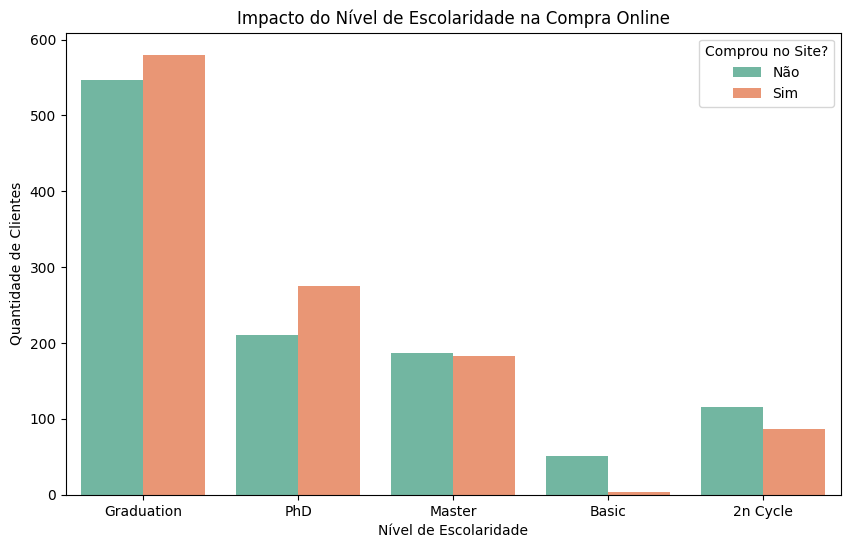

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Education', hue='WebPurchases', data=df, palette='Set2')
plt.title('Impacto do Nível de Escolaridade na Compra Online')
plt.xlabel('Nível de Escolaridade')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Comprou no Site?', labels=['Não', 'Sim'])
plt.show()

O gráfico revela que clientes com ensino superior (Graduação, Mestrado e PhD) têm uma propensão de compra online maior que o nível básico. Isso indica uma barreira de conveniência para pessoas com menor escolaridade.

**Relação Renda vs. Estado Civil**

C:\Users\Rafael\AppData\Local\Temp\ipykernel_19416\3188747960.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Marital_Status', y='Income', data=df[df['Income'] < 150000], palette='pastel')


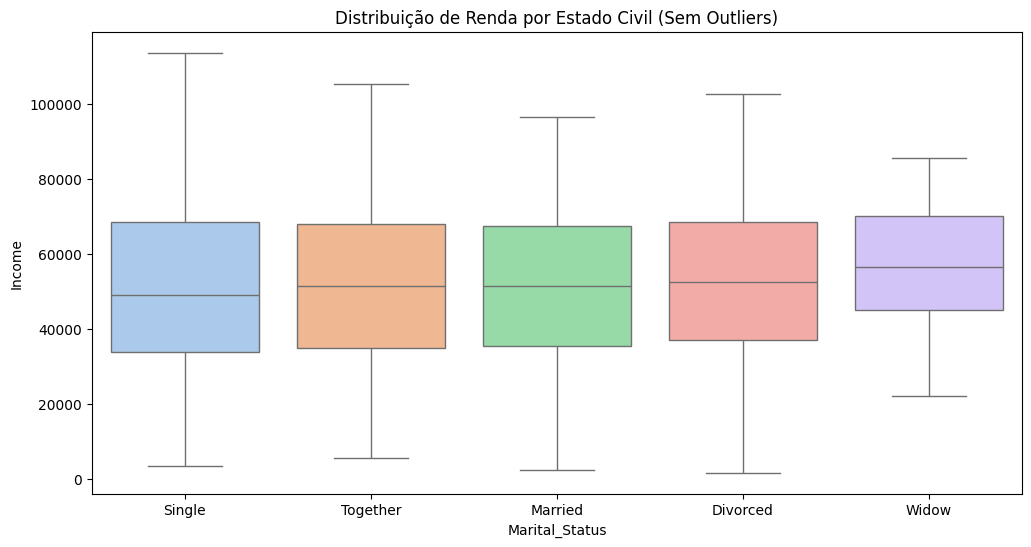

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Marital_Status', y='Income', data=df[df['Income'] < 150000], palette='pastel')
plt.title('Distribuição de Renda por Estado Civil (Sem Outliers)')
plt.show()

A distribuição de renda (mediana e quartis) é similar entre os grupos, com uma leve vantagem em estabilidade para os grupos "Married" e "Together".

O estado civil por si só, não é um limitador de poder de compra nesta amostra. o volume de compradores web é maior em casais (Married/Together).

**Densidade de Renda por Conversão Web**

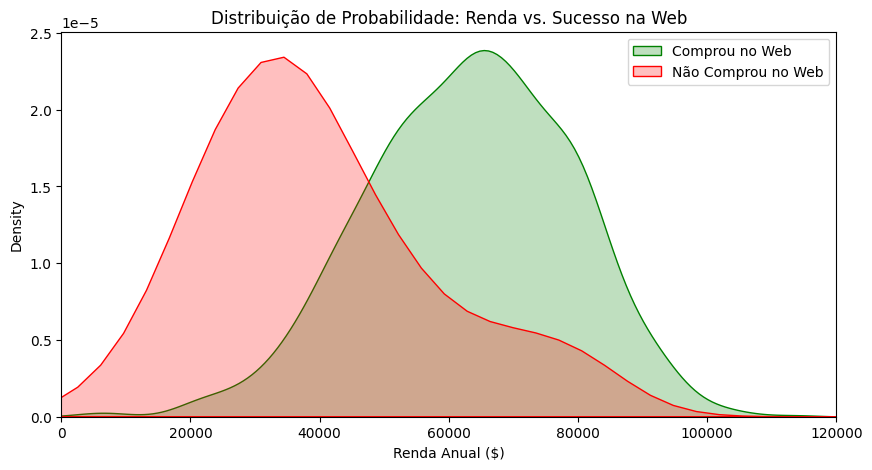

In [13]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['WebPurchases'] == 1], x='Income', label='Comprou no Web', fill=True, color='green')
sns.kdeplot(data=df[df['WebPurchases'] == 0], x='Income', label='Não Comprou no Web', fill=True, color='red')
plt.title('Distribuição de Probabilidade: Renda vs. Sucesso na Web')
plt.xlabel('Renda Anual ($)')
plt.xlim(0, 120000)
plt.legend()
plt.show()

Observamos que a curva de compradores (verde) é muito mais acentuado do que os não-compradores a partir dos $50.000. Isso indica que o canal web não é apenas um local de conveniência, mas um canal preferencial para clientes de médio-alto poder aquisitivo.

## ETAPA 2: Pré-processamento

Nesta etapa será realizado as seguintes atividades:

1. **Análise de Correlação**: Avaliar a interdependência estatística entre as variáveis para identificar e, se necessário, excluir aquelas cuja relevância para o modelo é limitada ou nula.
2. **Codificação de Variáveis Categóricas**: Converter as variáveis de natureza categórica para uma representação numérica, possibilitando seu processamento pelos algoritmos de machine learning.
3. **Particionamento da Base de Dados (Variáveis Alvo, Preditivas, Treinamento e Teste)**: Efetuar a separação do conjunto de dados nas variáveis preditoras (X) e na variável alvo (Y), procedendo, subsequentemente, à subdivisão de X e Y em subconjuntos destinados ao treinamento e à validação (teste).
4. **Padronização ou Normalização dos Dados**: Implementar a padronização dos dados ou a normalização (quando aplicável) com o objetivo de otimizar a performance e a robustez do modelo.

### 2.1 - Análise de Correlação e Seleção de Atributos

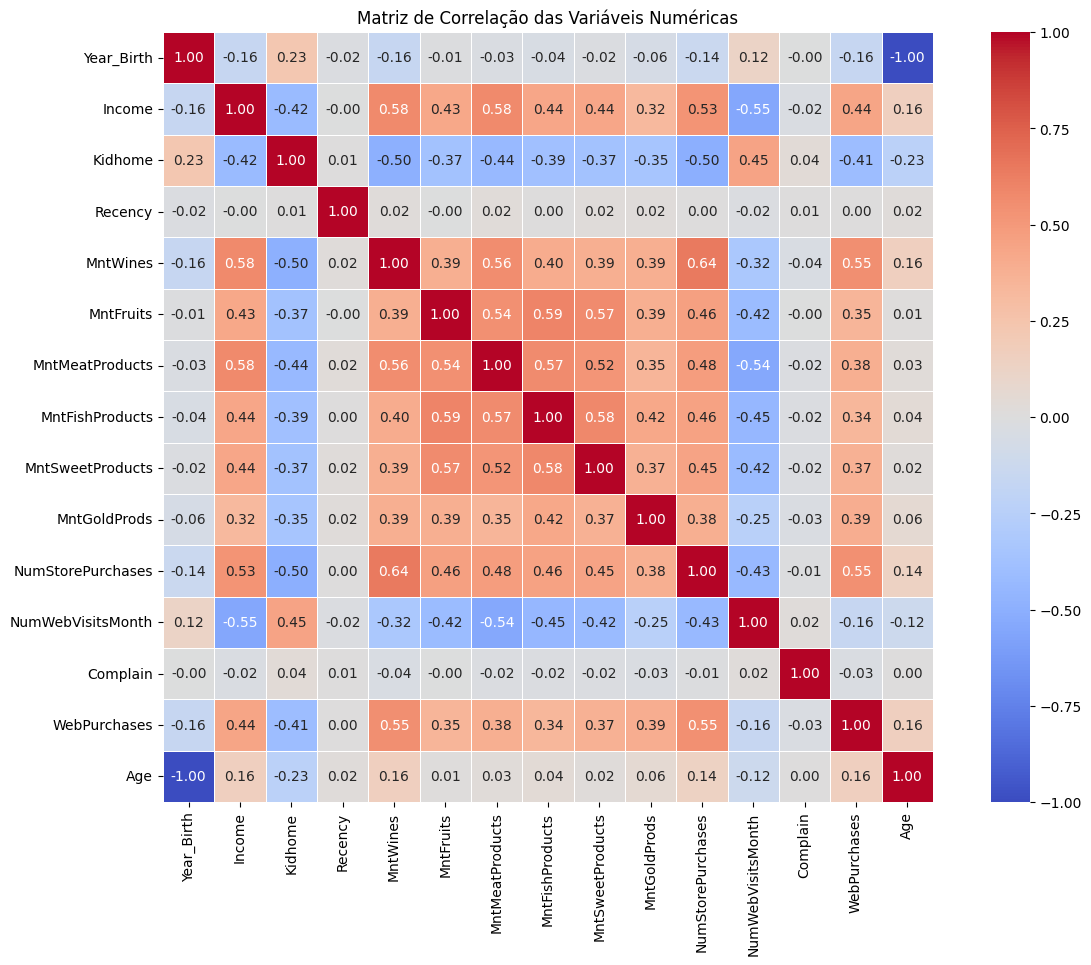

WebPurchases         1.000000
MntWines             0.549889
NumStorePurchases    0.546522
Income               0.437799
MntGoldProds         0.392923
MntMeatProducts      0.384419
MntSweetProducts     0.369100
MntFruits            0.347958
MntFishProducts      0.338049
Age                  0.162027
Recency              0.000899
Complain            -0.029217
NumWebVisitsMonth   -0.160957
Year_Birth          -0.162027
Kidhome             -0.408184
Name: WebPurchases, dtype: float64


In [15]:
# 1. Cálculo da Matriz de Correlação (Apenas Numéricos)
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

# 2. Visualização com Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

# 3. Análise da correlação com o Alvo (WebPurchases)
print(corr_matrix['WebPurchases'].sort_values(ascending=False))

**Insights**

**Redundância**: A variável ``Year_Birth` tem uma correlação perfeita negativa com a nossa variável que criamos `Age` (-1.00). Por isso, decidimos remover Year_Birth, pois a idade é mais intuitiva e evita multicolinearidade.

**Variáveis Preditores**: `MntWines` (0.55) e `NumStorePurchases` (0.55) são os indicadores mais fortes de quem compra no site. Quem já consome vinhos e frequenta a loja física tende a usar o site.

**Variáveis Fracas**: `Complain` e `Recency` possuem correlação próxima de zero com o sucesso na Web. No entanto, por questões de contexto de negócio (saber se o cliente reclamou é importante), manteremos estas variáveis para ver como o modelo de Árvore se comporta.

**Impacto**: Kidhome (-0.41) mostra que clientes com crianças em casa tendem a comprar menos pelo site.

### 2.2 Codificação de Variáveis Categóricas (Encoding)

Modelos matemáticos não entendem "PhD" ou "Married". Transformamos estas palavras em números usando o One-Hot Encoding

In [16]:
# Definindo as variáveis preditoras (X) e o alvo (y)
# Removemos Year_Birth (redundante com Age)
X = df.drop(['WebPurchases', 'Year_Birth'], axis=1)
y = df['WebPurchases']

# Aplicação do One-Hot Encoding
# Usamos drop_first=True para evitar a armadilha da multicolinearidade
X_encoded = pd.get_dummies(X, columns=['Education', 'Marital_Status'], drop_first=True)

print(f"Colunas originais: {X.shape[1]} | Colunas após Encoding: {X_encoded.shape[1]}")

Colunas originais: 15 | Colunas após Encoding: 21


### 2.3. Separação em Treino e Teste
Dividimos a base para que o modelo aprenda num grupo e seja testado num grupo "inédito", garantindo que ele não decorou os dados (Overfitting).

In [17]:
# Divisão 80/20
# stratify=y garante que a proporção de compradores/não-compradores seja igual nos dois grupos
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

### 2.4. Padronização dos Dados (Scaling)
Como temos variáveis em escalas muito diferentes, usamos o `StandardScaler`. Isso coloca todos os dados na mesma "grandeza" (média 0 e desvio padrão 1).

In [18]:
# Identificamos apenas as colunas que eram originalmente numéricas para não padronizar os 0s e 1s das categorias
num_cols = ['Income', 'Kidhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumStorePurchases', 
            'NumWebVisitsMonth', 'Complain', 'Age']

scaler = StandardScaler()

# O Scaler deve "aprender" (fit) apenas com os dados de TREINO para evitar vazamento de dados
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Padronização concluída com sucesso!")

Padronização concluída com sucesso!


## ETAPA 3: Modelagem

Vamos atuar com os modelos de Regressão logistica e Random Forest para essa base. no final vamos fazer um comparativo destes dois modelos
Optei por uma abordagem comparativa didática. Comecei com a Regressão Logística para estabelecer um baseline e entender a relação linear das variáveis (como Renda e Idade).
como poderiam tem padrões não lineares envolvendo as variáveis, a utilização do Random forest poderia transpor os limites da regressão logistica e mostrar mais detalhes e desempenho

### 3.1 - MODELO 1: REGRESSÃO LOGÍSTICA

In [19]:
print("iniciando treinamento da Regressão Logística...")

# 1. Instanciar
modelo_logistico = LogisticRegression(random_state=42, max_iter=1000)

# 2. Treinar (Fit)
modelo_logistico.fit(X_train, y_train)

# 3. Prever (Predict)
y_pred_log = modelo_logistico.predict(X_test)

# 4. Avaliação Individual
print("\n--- Relatório de Performance: Regressão Logística ---")
print(classification_report(y_test, y_pred_log))

iniciando treinamento da Regressão Logística...

--- Relatório de Performance: Regressão Logística ---
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       222
           1       0.87      0.84      0.85       226

    accuracy                           0.85       448
   macro avg       0.86      0.86      0.85       448
weighted avg       0.86      0.85      0.85       448



### 3.2 - MODELO 2: RANDOM FOREST

In [20]:
print("iniciando treinamento do Random Forest...")

# 1. Instanciar
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Treinar (Fit)
modelo_rf.fit(X_train, y_train)

# 3. Prever (Predict)
y_pred_rf = modelo_rf.predict(X_test)

# 4. Avaliação Individual
print("\n--- Relatório de Performance: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

iniciando treinamento do Random Forest...

--- Relatório de Performance: Random Forest ---
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       222
           1       0.91      0.94      0.92       226

    accuracy                           0.92       448
   macro avg       0.92      0.92      0.92       448
weighted avg       0.92      0.92      0.92       448



## ETAPA 4: Avaliação

### 4.1 - Visualização dos Resultados

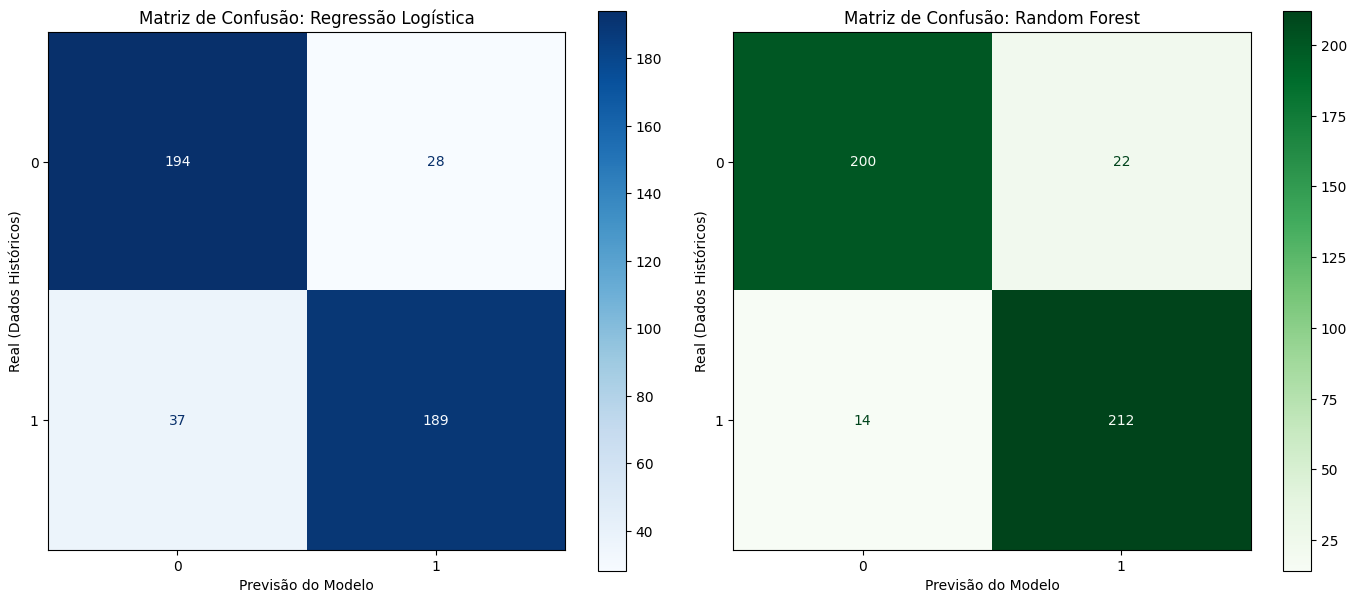

In [21]:
# Configuração da área de plotagem (Tamanho dos gráficos)
# Vamos criar uma figura com 2 subplots lado a lado para as Matrizes de Confusão
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- 1. MATRIZES DE CONFUSÃO (HEATMAPS) ---
# Visual: Regressão Logística
ConfusionMatrixDisplay.from_estimator(modelo_logistico, X_test, y_test, ax=ax[0], cmap='Blues')
ax[0].set_title('Matriz de Confusão: Regressão Logística')
ax[0].set_xlabel('Previsão do Modelo')
ax[0].set_ylabel('Real (Dados Históricos)')

# Visual: Random Forest
ConfusionMatrixDisplay.from_estimator(modelo_rf, X_test, y_test, ax=ax[1], cmap='Greens')
ax[1].set_title('Matriz de Confusão: Random Forest')
ax[1].set_xlabel('Previsão do Modelo')
ax[1].set_ylabel('Real (Dados Históricos)')

plt.tight_layout()
plt.show()


**Matriz de Confusão**

Avaliando os modelos, podemos verificar que o **Random Forest** cometeu menos erros graves(Falsosn negativos). Apenas resaltando que quando mais escuro a diagonal da matriz (cruzamento de 1:1 e 0:0) mais o modelo acertou em suas previsão.

c:\Users\Rafael\Dev\ciencia_de_dados_v2\venv3_14\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


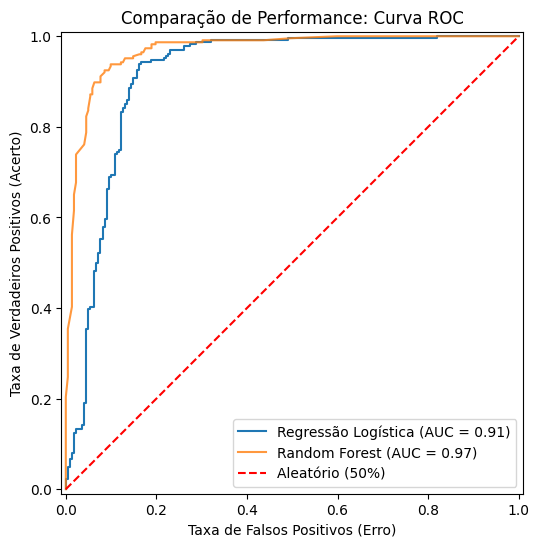

In [22]:
# --- 2. CURVA ROC COMPARATIVA ---
# A Curva ROC mostra a relação entre acertar os positivos e errar os negativos.
# Quanto mais a linha estiver no canto superior esquerdo, melhor.

plt.figure(figsize=(10, 6))
ax_roc = plt.gca() 

# Plotar Logística
visual_log = RocCurveDisplay.from_estimator(modelo_logistico, X_test, y_test, ax=ax_roc, name='Regressão Logística')

# Plotar Random Forest (no mesmo gráfico)
visual_rf = RocCurveDisplay.from_estimator(modelo_rf, X_test, y_test, ax=ax_roc, name='Random Forest', alpha=0.8)

ax_roc.set_title('Comparação de Performance: Curva ROC')
ax_roc.set_xlabel('Taxa de Falsos Positivos (Erro)')
ax_roc.set_ylabel('Taxa de Verdadeiros Positivos (Acerto)')
ax_roc.legend(loc="lower right")

plt.title('Comparação de Performance: Curva ROC')
plt.plot([0, 1], [0, 1], 'r--', label='Aleatório (50%)')
plt.legend()
plt.show()


**Curva ROC**

É possivel verificar que a linha do **Random Forest passa acima** da linha da Regressão Logística. Isso prova visualmente que ele é superior em quase todas as decisão. A área abaixo da curva (AUC) será maior (mais próxima de 1.0).

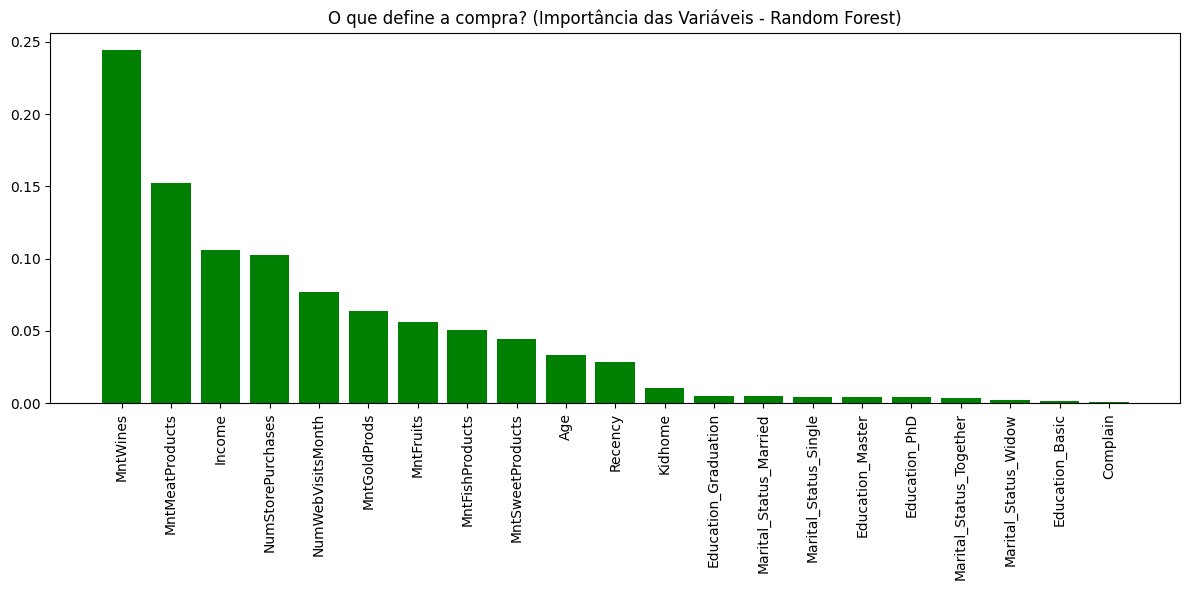

In [ ]:
# --- 3. IMPORTÂNCIA DAS VARIÁVEIS (Apenas Random Forest) ---
# Descobrir o que faz o cliente comprar!

importances = modelo_rf.feature_importances_
indices = np.argsort(importances)[::-1]
nomes_features = X_train.columns

plt.figure(figsize=(12, 6))
plt.title("O que define a compra? (Importância das Variáveis - Random Forest)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center", color='green')
plt.xticks(range(X_train.shape[1]), nomes_features[indices], rotation=90)
plt.tight_layout()
plt.show()

**Feature Importance**

Aqui podemos identificar claramente que o consumo de vinhos é o maior preditor de compras online.

In [24]:
# ==========================================================
# COMPARAÇÃO FINAL
# ==========================================================
print("\n" + "="*50 + "\n")
print("--- Comparativo de Resultados (Acurácia Global) ---")

acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Regressão Logística: {acc_log:.2%}")
print(f"Random Forest:       {acc_rf:.2%}")

if acc_rf > acc_log:
    diff = (acc_rf - acc_log) * 100
    print(f"\nCONCLUSÃO: O Random Forest foi superior em mais de {diff:.2f} pontos percentuais.")
else:
    print(f"\nCONCLUSÃO: A Regressão Logística apresentou melhor performance.")



--- Comparativo de Resultados (Acurácia Global) ---
Regressão Logística: 85.49%
Random Forest:       91.96%

CONCLUSÃO: O Random Forest foi superior em mais de 6.47 pontos percentuais.
